# cNMF with gene filter > 10% & HVG = 2000
- subset cells initially annotated as `Tumor`, `OPC` and `COP`
- run cNMF and find gene signatures for further & accurate cell type annotation

In [9]:
import warnings
warnings.simplefilter('ignore')
import os
import scanpy as sc
import numpy as np

In [5]:
output_path = 'forNMF/tumor'
data_path = '../output/'
plot_path = '../plot/'
marker_path = '../markers/'

# 1. Subset tumor, then re-normalize & re-integration with scVI with full dimensions
- run with L4 (python 3.11, Pytorch 2.4)
- i'll just use default parameter in this case

In [2]:
!pip install scanpy scikit-misc scvi-tools mplscience igraph leidenalg

  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of orbax-checkpoint to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 81.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 167.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 152.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 135.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 123.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.3/87.3 MB 119.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 815.2/815.2 kB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 205.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 174.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 170.6 MB/s eta 0:00:00
   ━━━━━━━

In [3]:
import os
os.chdir('/workspace')
import gc
import warnings
warnings.filterwarnings("ignore")

# single cell pipelines
import scanpy as sc
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import mplscience

# scvi-tools
import scvi
import torch

print(scvi.__version__)
sc.logging.print_header()

np.random.seed(777)
torch.manual_seed(777)
scvi.settings.seed = 777

torch.set_float32_matmul_precision("high")

1.3.0


Seed set to 777


In [10]:
adata = sc.read_h5ad('annotated_redo_2025.h5ad')

In [11]:
adata = adata.raw.to_adata()
adata.layers['counts'] = adata.X.copy()
adata = adata[adata.obs.sample_id.str.startswith('Mouse')].copy()
adata = adata[adata.obs.cell_type.isin(['Tumor'])].copy()
adata

AnnData object with n_obs × n_vars = 16777 × 29009
    obs: 'sample_id', 'sample_info', 'age', 'sex', 'barcode', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'scDblFinder_score', 'scDblFinder_class', 'doublet_score', 'predicted_doublet', 'cell_type', 'grade', 'GFP', 'leiden_res1', 'wb_anno', 'wb_conf_score', 'cellid_prediction', 'leiden_res2', 'new_cell_type', 'old_cell_type', 'leiden', 'predicted_labels', 'conf_score', 'each_cell_type'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'neighbors', 'sample_info_colors', 'umap'
    obsm: 'X_scANVI', 'X_scVI', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [12]:
np.min(np.sum(adata.X, axis=1)), np.min(np.sum(adata.X, axis=0))

(1271.0, 0.0)

In [13]:
# filter genes with low expression
sc.pp.filter_genes(adata, min_cells = int(adata.shape[0]*0.1))

In [14]:
adata.shape

(16777, 10652)

In [15]:
adata.obs.sample_id.value_counts()

sample_id
Mouse1    6462
Mouse4    6077
Mouse2    4212
Mouse3      26
Name: count, dtype: int64

In [16]:
# renormalize with scVI
scvi.model.SCVI.setup_anndata(adata, layer='counts', batch_key='sample_id' , continuous_covariate_keys=['pct_counts_mt', 'pct_counts_ribo'])
model = scvi.model.SCVI(adata)
model.train(early_stopping=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/400 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 45 records. Best score: 11405.446. Signaling Trainer to stop.


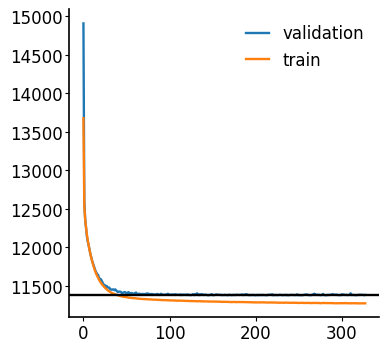

In [17]:
with mplscience.style_context():
    y = model.history['reconstruction_loss_validation']['reconstruction_loss_validation'].min()
    plt.plot(model.history['reconstruction_loss_validation']['reconstruction_loss_validation'], label = 'validation')
    plt.plot(model.history['reconstruction_loss_train']['reconstruction_loss_train'], label = 'train')

    plt.axhline(y, c = 'k')
    plt.legend()
    plt.show()

In [18]:
adata.X = adata.layers['counts'].toarray()
adata.obsm['X_scVI'] = model.get_latent_representation()
adata.layers['scvi_normalized'] = model.get_normalized_expression(library_size=1e4)

In [19]:
sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.leiden(adata)
sc.tl.umap(adata)

In [21]:
adata.write('subcluster.h5ad')
model.save('model_subcluster.model')

In [22]:
adata.X = adata.layers['scvi_normalized']
adata.write_h5ad('subcluster_scvi.h5ad')

- run scVI with HVG

In [23]:
adata = sc.read_h5ad('annotated_redo_2025.h5ad')
adata = adata.raw.to_adata()
adata.layers['counts'] = adata.X.copy()
adata = adata[adata.obs.sample_id.str.startswith('Mouse')].copy()
adata = adata[adata.obs.cell_type.isin(['Tumor'])].copy()
adata

AnnData object with n_obs × n_vars = 16777 × 29009
    obs: 'sample_id', 'sample_info', 'age', 'sex', 'barcode', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'scDblFinder_score', 'scDblFinder_class', 'doublet_score', 'predicted_doublet', 'cell_type', 'grade', 'GFP', 'leiden_res1', 'wb_anno', 'wb_conf_score', 'cellid_prediction', 'leiden_res2', 'new_cell_type', 'old_cell_type', 'leiden', 'predicted_labels', 'conf_score', 'each_cell_type'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'neighbors', 'sample_info_colors', 'umap'
    obsm: 'X_scANVI', 'X_scVI', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [24]:
sc.pp.filter_genes(adata, min_cells = int(adata.shape[0]*0.1))

In [25]:
adata.raw = adata # save dimensions
sc.pp.highly_variable_genes(adata, n_top_genes = 2000, subset = True, layer = 'counts', flavor = 'seurat_v3', batch_key = 'sample_id') 

In [26]:
np.min(np.sum(adata.X, axis=1)), np.min(np.sum(adata.X, axis=0))

(228.0, 1898.0)

In [27]:
adata

AnnData object with n_obs × n_vars = 16777 × 2000
    obs: 'sample_id', 'sample_info', 'age', 'sex', 'barcode', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'pct_counts_mt', 'pct_counts_ribo', 'pct_counts_hb', 'scDblFinder_score', 'scDblFinder_class', 'doublet_score', 'predicted_doublet', 'cell_type', 'grade', 'GFP', 'leiden_res1', 'wb_anno', 'wb_conf_score', 'cellid_prediction', 'leiden_res2', 'new_cell_type', 'old_cell_type', 'leiden', 'predicted_labels', 'conf_score', 'each_cell_type'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'n_cells', 'highly_variable_rank', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'neighbors', 'sample_info_colors', 'umap', 'hvg'
    obsm: 'X_scANVI', 'X_scVI', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [29]:
with open('hvgs.txt', 'w') as f:
    for gene in adata.var_names:
        f.write(gene + '\n')